<a href="https://colab.research.google.com/github/Vane-UNCP/tecemer-lab1/blob/main/SEMANA6/Ejercicio_03a_CNN_Clasificacion_Imagenes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 3a — Redes Neuronales Convolucionales (CNN): Clasificación de Imágenes
### Tecnologías Emergentes (ISO46B) — Material complementario de comprensión conceptual

Notebook **autocontenido** para **Google Colab** (`Entorno de ejecución > Ejecutar todas`). Usa el dataset **Fashion-MNIST**, incluido en Keras y descargado automáticamente la primera vez que se usa (no requiere subir archivos).

**Objetivo:** entender por qué las CNN son la arquitectura natural para imágenes, ver "por dentro" qué aprende cada capa (filtros y mapas de características) y evaluar visualmente los resultados.


## 0. Configuración inicial

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

sns.set_style("white")
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


## 1. Cargar y explorar los datos

CIFAR-10 contiene 60,000 imágenes a color (RGB) de 32×32 píxeles, divididas en 10 categorías de objetos y animales cotidianos.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1273s 7us/step
X_train: (50000, 32, 32, 3)  X_test: (10000, 32, 32, 3)


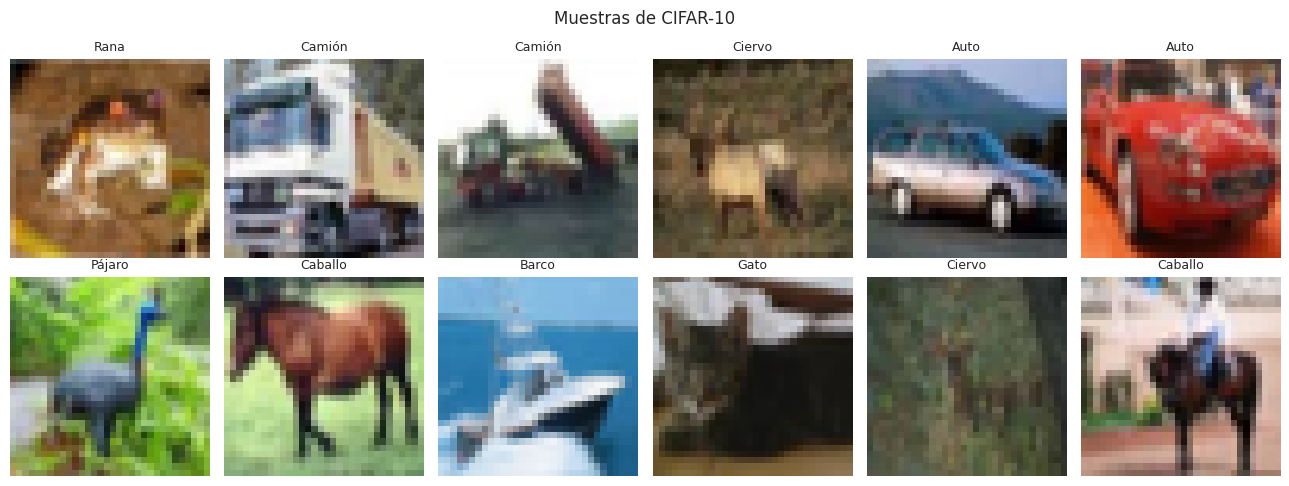

In [2]:
from tensorflow import keras
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Reducir dimensiones de las etiquetas para facilitar el procesamiento
y_train = y_train.squeeze()
y_test = y_test.squeeze()

NOMBRES_CLASES = ["Avión", "Auto", "Pájaro", "Gato", "Ciervo",
                   "Perro", "Rana", "Caballo", "Barco", "Camión"]

print("X_train:", X_train.shape, " X_test:", X_test.shape)

fig, ejes = plt.subplots(2, 6, figsize=(13, 5))
for i, ax in enumerate(ejes.flat):
    ax.imshow(X_train[i])
    ax.set_title(NOMBRES_CLASES[y_train[i]], fontsize=9)
    ax.axis("off")
plt.suptitle("Muestras de CIFAR-10")
plt.tight_layout()
plt.show()

## 2. ¿Por qué una CNN y no un MLP simple?

Una imagen de 28×28 aplanada tiene 784 valores. Una capa `Dense` conectada a esos 784 valores con, digamos, 128 neuronas ya usa **más de 100,000 parámetros solo en la primera capa** — y esto **ignora por completo la posición espacial** de los píxeles (aplanar una imagen destruye la información de "qué está al lado de qué").

Una **capa convolucional** en cambio desliza un pequeño filtro (ej. 3×3) sobre toda la imagen, reutilizando los mismos pesos en cada posición. Esto:
1. Reduce drásticamente el número de parámetros.
2. Preserva y explota la estructura espacial (bordes, texturas, formas).
3. Aprende patrones que son **invariantes a la posición** (un filtro que detecta un borde vertical lo detecta esté donde esté en la imagen).

In [3]:
parametros_mlp_capa1 = 32 * 32 * 3 * 128 + 128
parametros_conv_capa1 = (3 * 3 * 3) * 32 + 32  # 32 filtros de 3x3 sobre 3 canales (RGB)

print(f"Parámetros de una capa Dense(128) sobre la imagen aplanada: {parametros_mlp_capa1:,}")
print(f"Parámetros de una capa Conv2D(32, kernel 3x3):              {parametros_conv_capa1:,}")
print(f"\n-> La capa convolucional usa {parametros_mlp_capa1 / parametros_conv_capa1:.0f}x menos parámetros "
      f"en esta primera capa, y aun así puede cubrir toda la imagen conservando la estructura de color.")

Parámetros de una capa Dense(128) sobre la imagen aplanada: 393,344
Parámetros de una capa Conv2D(32, kernel 3x3):              896

-> La capa convolucional usa 439x menos parámetros en esta primera capa, y aun así puede cubrir toda la imagen conservando la estructura de color.


## 3. Preparar los datos

In [4]:
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0

# CIFAR-10 ya tiene la forma (32, 32, 3), por lo que solo verificamos las dimensiones
print("Forma final:", X_train_norm.shape, " Rango de valores:", X_train_norm.min(), "a", X_train_norm.max())

Forma final: (50000, 32, 32, 3)  Rango de valores: 0.0 a 1.0


## 4. Construir la arquitectura CNN

Arquitectura clásica: dos bloques `Conv2D + MaxPooling2D` (extracción de características), seguidos de `Flatten + Dense` (clasificación).

In [5]:
modelo_cnn = keras.Sequential([
    layers.Input(shape=(32, 32, 3)), # Ajustado para imágenes de 32x32x3
    layers.Conv2D(32, kernel_size=3, activation="relu", name="conv_1"),
    layers.MaxPooling2D(pool_size=2, name="pool_1"),
    layers.Conv2D(64, kernel_size=3, activation="relu", name="conv_2"),
    layers.MaxPooling2D(pool_size=2, name="pool_2"),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
modelo_cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
modelo_cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

## 5. Entrenar y evaluar

In [6]:
historial = modelo_cnn.fit(
    X_train_norm, y_train, epochs=6, batch_size=128,
    validation_split=0.2, verbose=1,
)

Epoch 1/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 149ms/step - accuracy: 0.3602 - loss: 1.7517 - val_accuracy: 0.4790 - val_loss: 1.4678
Epoch 2/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 139ms/step - accuracy: 0.5086 - loss: 1.3779 - val_accuracy: 0.5372 - val_loss: 1.3312
Epoch 3/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 142ms/step - accuracy: 0.5610 - loss: 1.2448 - val_accuracy: 0.5686 - val_loss: 1.2320
Epoch 4/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 137ms/step - accuracy: 0.5989 - loss: 1.1489 - val_accuracy: 0.5935 - val_loss: 1.1671
Epoch 5/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 138ms/step - accuracy: 0.6276 - loss: 1.0744 - val_accuracy: 0.6131 - val_loss: 1.1161
Epoch 6/6
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 140ms/step - accuracy: 0.6454 - loss: 1.0195 - val_accuracy: 0.6315 - val_loss: 1.0735


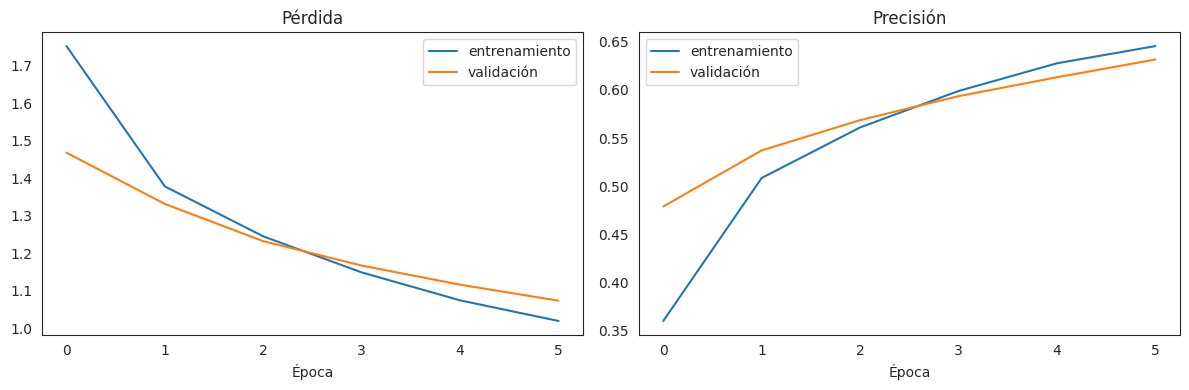

Precisión en test: 0.6326


In [7]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))
ejes[0].plot(historial.history["loss"], label="entrenamiento")
ejes[0].plot(historial.history["val_loss"], label="validación")
ejes[0].set_title("Pérdida"); ejes[0].set_xlabel("Época"); ejes[0].legend()
ejes[1].plot(historial.history["accuracy"], label="entrenamiento")
ejes[1].plot(historial.history["val_accuracy"], label="validación")
ejes[1].set_title("Precisión"); ejes[1].set_xlabel("Época"); ejes[1].legend()
plt.tight_layout()
plt.show()

perdida_test, precision_test = modelo_cnn.evaluate(X_test_norm, y_test, verbose=0)
print(f"Precisión en test: {precision_test:.4f}")

## 6. Ver "por dentro" de la red: filtros aprendidos

Cada filtro de la primera capa convolucional es una pequeña "plantilla" (3×3 en este caso) que la red aprendió para detectar un patrón específico (bordes, texturas...).

Forma de los filtros: (3, 3, 3, 32)


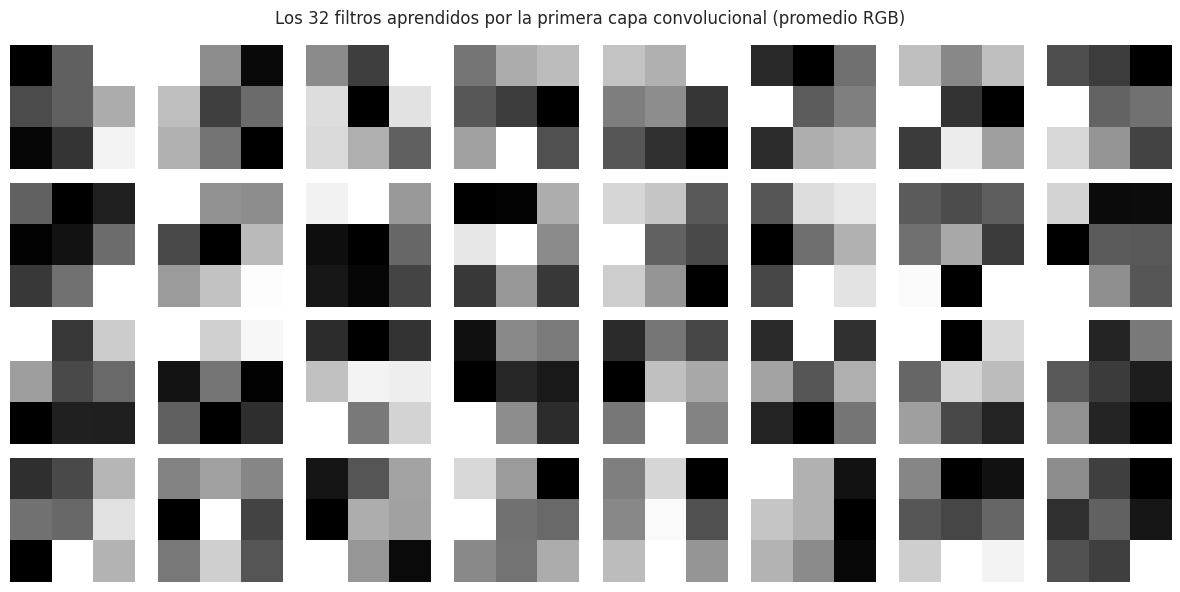

In [8]:
pesos_conv1, sesgos_conv1 = modelo_cnn.get_layer("conv_1").get_weights()
print("Forma de los filtros:", pesos_conv1.shape)  # (alto, ancho, canales_entrada, n_filtros)

# Dado que los filtros operan sobre 3 canales (RGB), visualizaremos su magnitud o promedio por canal para simplificar
fig, ejes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(ejes.flat):
    # Promedio sobre los 3 canales de entrada para visualizar el filtro en 2D
    filtro = np.mean(pesos_conv1[:, :, :, i], axis=2)
    ax.imshow(filtro, cmap="gray")
    ax.axis("off")
plt.suptitle("Los 32 filtros aprendidos por la primera capa convolucional (promedio RGB)")
plt.tight_layout()
plt.show()

## 7. Mapas de características (feature maps)

Aplicamos la red a una sola imagen y observamos la salida de cada capa convolucional: cada "rebanada" muestra dónde un filtro específico "se activó" (detectó su patrón).

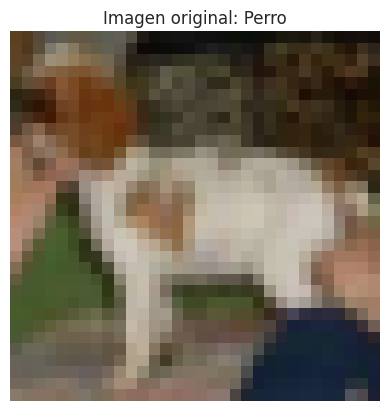

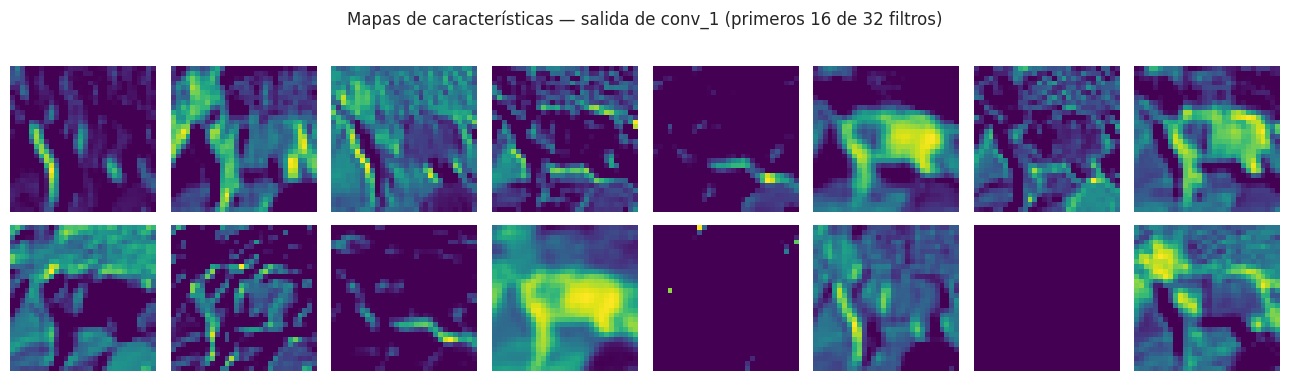

In [9]:
modelo_extractor = keras.Model(inputs=modelo_cnn.inputs,
                                outputs=[modelo_cnn.get_layer("conv_1").output,
                                         modelo_cnn.get_layer("conv_2").output])

indice_muestra = 12
imagen_muestra = X_test_norm[indice_muestra:indice_muestra + 1]
mapas_conv1, mapas_conv2 = modelo_extractor.predict(imagen_muestra, verbose=0)

plt.imshow(X_test[indice_muestra])
plt.title(f"Imagen original: {NOMBRES_CLASES[y_test[indice_muestra]]}")
plt.axis("off")
plt.show()

fig, ejes = plt.subplots(2, 8, figsize=(13, 4))
for i, ax in enumerate(ejes.flat):
    ax.imshow(mapas_conv1[0, :, :, i], cmap="viridis")
    ax.axis("off")
plt.suptitle("Mapas de características — salida de conv_1 (primeros 16 de 32 filtros)")
plt.tight_layout()
plt.show()

**Lectura:** cada "mini-imagen" es la respuesta de un filtro distinto sobre la prenda original. Algunos resaltan el contorno, otros una zona específica de textura — la red combina estas respuestas en capas posteriores para decidir la clase final.

## 8. Evaluación: matriz de confusión y errores

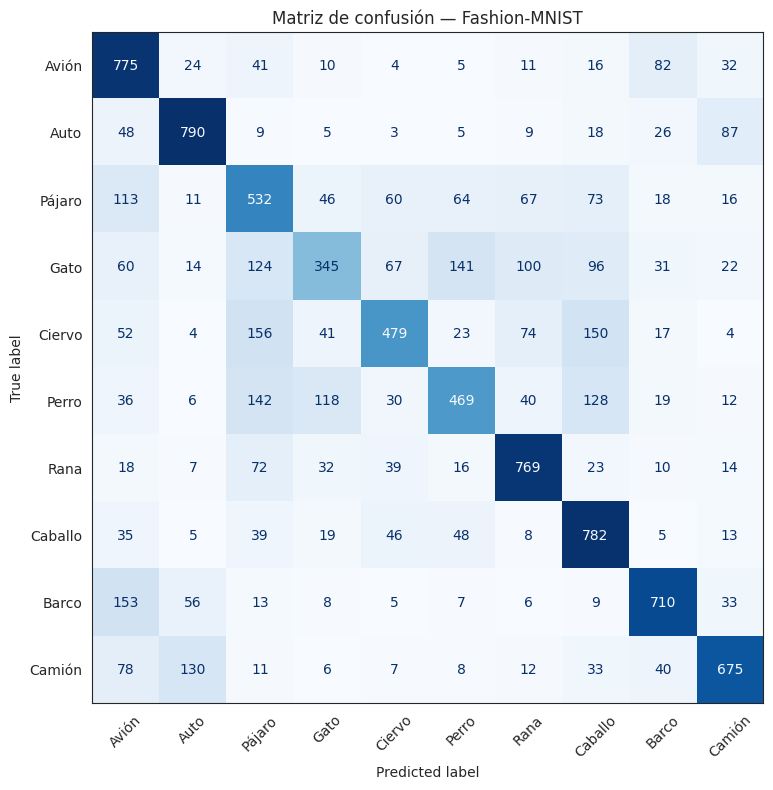

In [10]:
y_pred_probs = modelo_cnn.predict(X_test_norm, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=NOMBRES_CLASES).plot(
    ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)
plt.title("Matriz de confusión — Fashion-MNIST")
plt.tight_layout()
plt.show()

**Lectura:** si hay confusión notable, típicamente ocurre entre clases visualmente similares (p. ej. "Camiseta", "Suéter" y "Abrigo" son prendas superiores de forma parecida), no entre clases muy distintas como "Bolso" y "Sandalia".

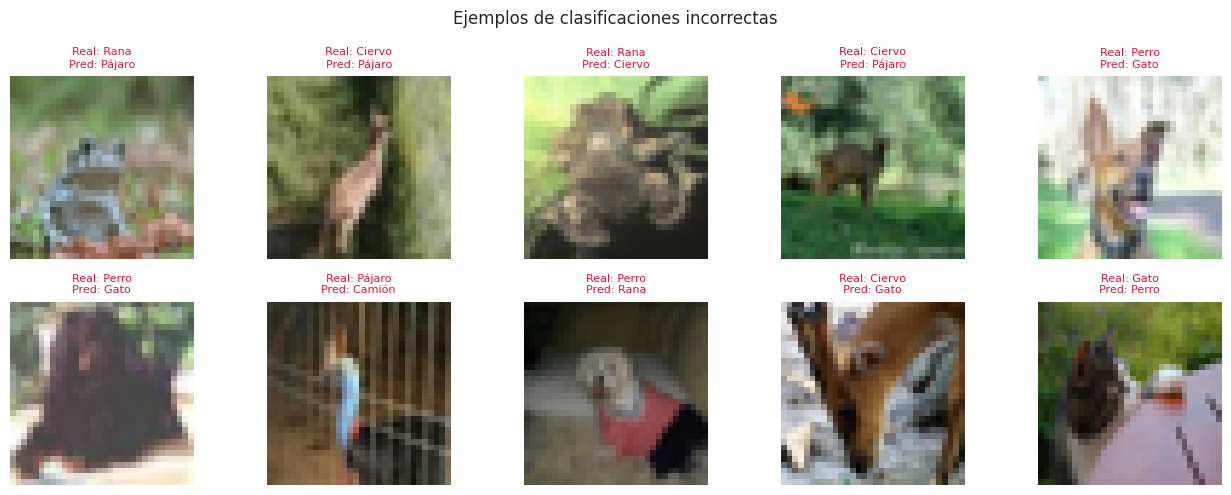

In [11]:
indices_error = np.where(y_pred != y_test)[0]
muestra_errores = np.random.choice(indices_error, size=min(10, len(indices_error)), replace=False)

fig, ejes = plt.subplots(2, 5, figsize=(13, 5))
for idx, ax in zip(muestra_errores, ejes.flat):
    ax.imshow(X_test[idx], cmap="gray")
    ax.set_title(f"Real: {NOMBRES_CLASES[y_test[idx]]}\nPred: {NOMBRES_CLASES[y_pred[idx]]}", fontsize=8, color="crimson")
    ax.axis("off")
plt.suptitle("Ejemplos de clasificaciones incorrectas")
plt.tight_layout()
plt.show()

## 9. Resumen

- Una CNN reemplaza conexiones densas masivas por **filtros compartidos** que recorren la imagen, reduciendo parámetros y preservando la estructura espacial.
- `Conv2D` extrae patrones locales; `MaxPooling2D` reduce la resolución conservando lo más relevante; `Flatten + Dense` combina esas características para clasificar.
- Los filtros y mapas de características son **interpretables**: se pueden visualizar para entender qué "ve" la red en cada capa.
- Esta misma arquitectura de bloques Conv+Pool es la base de tareas mucho más complejas, como la **detección de objetos** (Notebook 3b).
